<a href="https://colab.research.google.com/github/miwyayz/Building-Energy-Load-Prediction/blob/main/notebook/Perbandingan_Kinerja_Algoritma_Linear_Regression%2C_Random_Forest%2C_dan_Support_Vector_Regression_dalam_Prediksi_Konsumsi_Energi_Bangunan_Berdasarkan_Karakteristik_Desain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone

1. Data Understanding

In [ ]:
#1.1 Memuat dataset
df = pd.read_csv("ENB2012_data.csv")

kolom_baru = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}
df.rename(columns=kolom_baru, inplace=True)

print(f"  Jumlah baris    : {df.shape[0]}")
print(f"  Jumlah kolom    : {df.shape[1]}")

  Jumlah baris    : 768
  Jumlah kolom    : 10


In [ ]:
#1.2 Informasi Dataset
print("Deskripsi Fitur:")
deskripsi_fitur = {
    'Relative_Compactness'      : 'Kompaktasi relatif bangunan (X1)',
    'Surface_Area'              : 'Luas permukaan bangunan m² (X2)',
    'Wall_Area'                 : 'Luas dinding m² (X3)',
    'Roof_Area'                 : 'Luas atap m² (X4)',
    'Overall_Height'            : 'Tinggi keseluruhan bangunan m (X5)',
    'Orientation'               : 'Orientasi bangunan [2-5] (X6)',
    'Glazing_Area'              : 'Luas kaca [0, 0.1, 0.25, 0.4] (X7)',
    'Glazing_Area_Distribution' : 'Distribusi area kaca [0-5] (X8)',
    'Heating_Load'              : '>> TARGET: Beban pemanasan kWh/m² (Y1)',
    'Cooling_Load'              : '>> TARGET: Beban pendinginan kWh/m² (Y2)',
}
for col, desc in deskripsi_fitur.items():
    print(f"  {col:<35} : {desc}")

Deskripsi Fitur:
  Relative_Compactness                : Kompaktasi relatif bangunan (X1)
  Surface_Area                        : Luas permukaan bangunan m² (X2)
  Wall_Area                           : Luas dinding m² (X3)
  Roof_Area                           : Luas atap m² (X4)
  Overall_Height                      : Tinggi keseluruhan bangunan m (X5)
  Orientation                         : Orientasi bangunan [2-5] (X6)
  Glazing_Area                        : Luas kaca [0, 0.1, 0.25, 0.4] (X7)
  Glazing_Area_Distribution           : Distribusi area kaca [0-5] (X8)
  Heating_Load                        : >> TARGET: Beban pemanasan kWh/m² (Y1)
  Cooling_Load                        : >> TARGET: Beban pendinginan kWh/m² (Y2)


In [ ]:
#1.3 Tampilan Dataset
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [ ]:
#1.4 Tipe Data
df.dtypes

,0
Relative_Compactness,float64
Surface_Area,float64
Wall_Area,float64
Roof_Area,float64
Overall_Height,float64
Orientation,int64
Glazing_Area,float64
Glazing_Area_Distribution,int64
Heating_Load,float64
Cooling_Load,float64


In [ ]:
#Statistik Deskriptif
df.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


2. Data Preprocessing

In [ ]:
# 2.1 Pengecekan Missing Values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print(missing_df.to_string())
if df.isnull().sum().sum() == 0:
    print("\n  ✓ Tidak ada missing values dalam dataset!")
else:
    print("\n  ⚠ Ditemukan missing values, melakukan imputasi dengan median...")
    df.fillna(df.median(), inplace=True)
    print("  ✓ Missing values telah ditangani.")

                           Jumlah Missing  Persentase (%)
Relative_Compactness                    0             0.0
Surface_Area                            0             0.0
Wall_Area                               0             0.0
Roof_Area                               0             0.0
Overall_Height                          0             0.0
Orientation                             0             0.0
Glazing_Area                            0             0.0
Glazing_Area_Distribution               0             0.0
Heating_Load                            0             0.0
Cooling_Load                            0             0.0

  ✓ Tidak ada missing values dalam dataset!


In [ ]:
#2.2 Pengecekan Duplikasi
duplikat = df.duplicated().sum()
print(f"  Jumlah baris duplikat: {duplikat}")
if duplikat > 0:
    df.drop_duplicates(inplace=True)
    print(f"  ✓ {duplikat} baris duplikat dihapus. Dataset sekarang memiliki {len(df)} baris.")
else:
    print("  ✓ Tidak ada data duplikat.")


  Jumlah baris duplikat: 0
  ✓ Tidak ada data duplikat.


In [ ]:
 #2.3 Penanganan Outlier (IQR Method)
fitur_numerik = ['Relative_Compactness', 'Surface_Area', 'Wall_Area',
                 'Roof_Area', 'Overall_Height', 'Glazing_Area',
                 'Heating_Load', 'Cooling_Load']

outlier_info = {}
df_clean = df.copy()
for col in fitur_numerik:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    outlier_info[col] = {'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
                         'Lower Bound': lower, 'Upper Bound': upper,
                         'Jumlah Outlier': n_outlier}
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

outlier_df = pd.DataFrame(outlier_info).T[['Lower Bound', 'Upper Bound', 'Jumlah Outlier']]
print(outlier_df.to_string())
print("\n  ✓ Outlier ditangani dengan metode clipping (Winsorization).")
print(f"  Dataset bersih: {df_clean.shape[0]} baris × {df_clean.shape[1]} kolom")

                      Lower Bound  Upper Bound  Jumlah Outlier
Relative_Compactness      0.46125      1.05125             0.0
Surface_Area            404.25000    943.25000             0.0
Wall_Area               220.50000    416.50000             0.0
Roof_Area                21.43750    339.93750             0.0
Overall_Height           -1.75000     12.25000             0.0
Glazing_Area             -0.35000      0.85000             0.0
Heating_Load            -15.02000     59.68000             0.0
Cooling_Load            -10.64875     59.40125             0.0

  ✓ Outlier ditangani dengan metode clipping (Winsorization).
  Dataset bersih: 768 baris × 10 kolom


In [ ]:
#2.4 Encoding Variabel Kategorikal
print("  'Orientation' → One-Hot Encoding")
print("  'Glazing_Area_Distribution' → One-Hot Encoding")

df_encoded = pd.get_dummies(
    df_clean,
    columns=['Orientation', 'Glazing_Area_Distribution'],
    drop_first=True,
    dtype=int
)
print(f"  ✓ Setelah encoding, jumlah kolom: {df_encoded.shape[1]}")
print(f"  Kolom baru: {list(df_encoded.columns)}")

  'Orientation' → One-Hot Encoding
  'Glazing_Area_Distribution' → One-Hot Encoding
  ✓ Setelah encoding, jumlah kolom: 16
  Kolom baru: ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Heating_Load', 'Cooling_Load', 'Orientation_3', 'Orientation_4', 'Orientation_5', 'Glazing_Area_Distribution_1', 'Glazing_Area_Distribution_2', 'Glazing_Area_Distribution_3', 'Glazing_Area_Distribution_4', 'Glazing_Area_Distribution_5']


In [ ]:
#2.5 Memisahkan Fitur dan Target
TARGET_Y1 = 'Heating_Load'
TARGET_Y2 = 'Cooling_Load'

X = df_encoded.drop(columns=[TARGET_Y1, TARGET_Y2])
y1 = df_encoded[TARGET_Y1]
y2 = df_encoded[TARGET_Y2]

print(f"  Fitur (X) : {X.shape[1]} kolom → {list(X.columns)}")
print(f"  Target Y1 : {TARGET_Y1} (Heating Load)")
print(f"  Target Y2 : {TARGET_Y2} (Cooling Load)")

  Fitur (X) : 14 kolom → ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area', 'Overall_Height', 'Glazing_Area', 'Orientation_3', 'Orientation_4', 'Orientation_5', 'Glazing_Area_Distribution_1', 'Glazing_Area_Distribution_2', 'Glazing_Area_Distribution_3', 'Glazing_Area_Distribution_4', 'Glazing_Area_Distribution_5']
  Target Y1 : Heating_Load (Heating Load)
  Target Y2 : Cooling_Load (Cooling Load)


3. Visualisasi Data Eksplorasi (EDA)

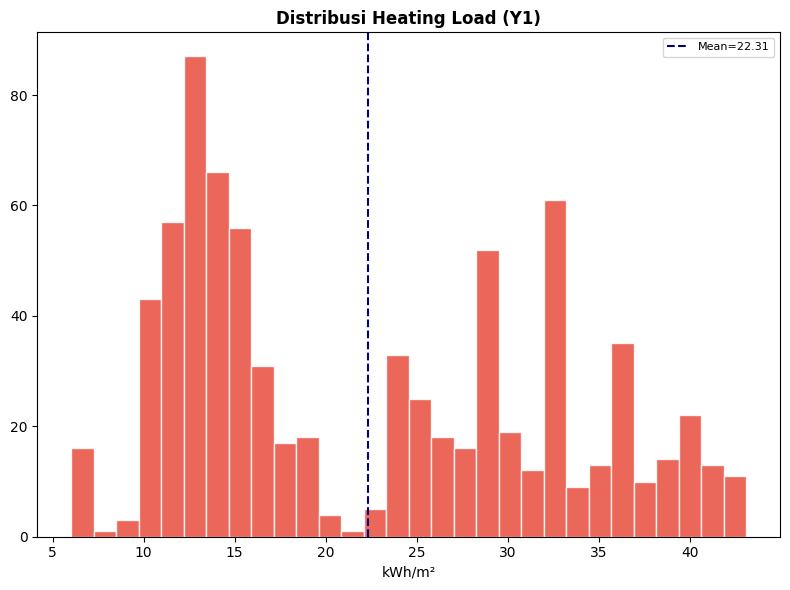

In [ ]:
# Plot 1: Distribusi Heating Load (Y1)
plt.figure(figsize=(8, 6))
plt.hist(df_clean['Heating_Load'], bins=30, color='#E74C3C', edgecolor='white', alpha=0.85)
plt.axvline(df_clean['Heating_Load'].mean(), color='navy', linestyle='--',
            label=f"Mean={df_clean['Heating_Load'].mean():.2f}")
plt.title('Distribusi Heating Load (Y1)', fontweight='bold')
plt.xlabel('kWh/m²')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

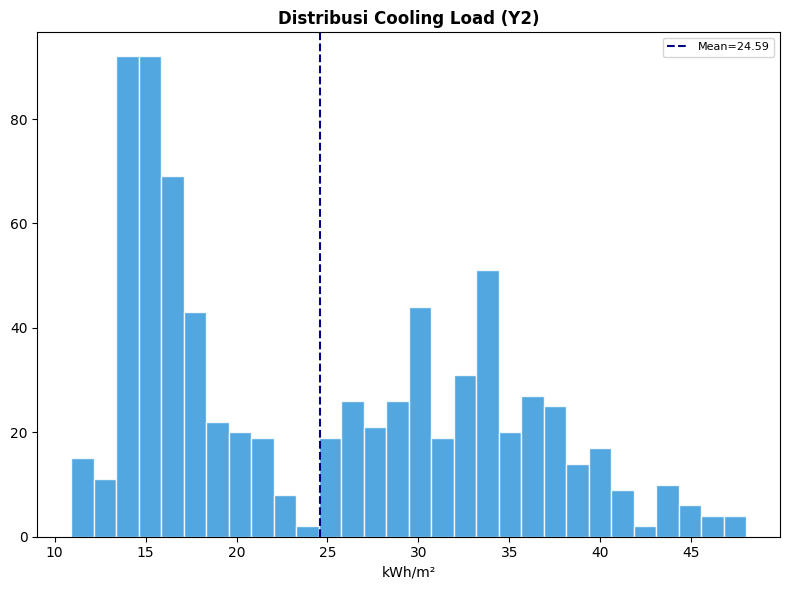

In [ ]:
# Plot 2: Distribusi Cooling Load (Y2)
plt.figure(figsize=(8, 6))
plt.hist(df_clean['Cooling_Load'], bins=30, color='#3498DB', edgecolor='white', alpha=0.85)
plt.axvline(df_clean['Cooling_Load'].mean(), color='navy', linestyle='--',
            label=f"Mean={df_clean['Cooling_Load'].mean():.2f}")
plt.title('Distribusi Cooling Load (Y2)', fontweight='bold')
plt.xlabel('kWh/m²')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

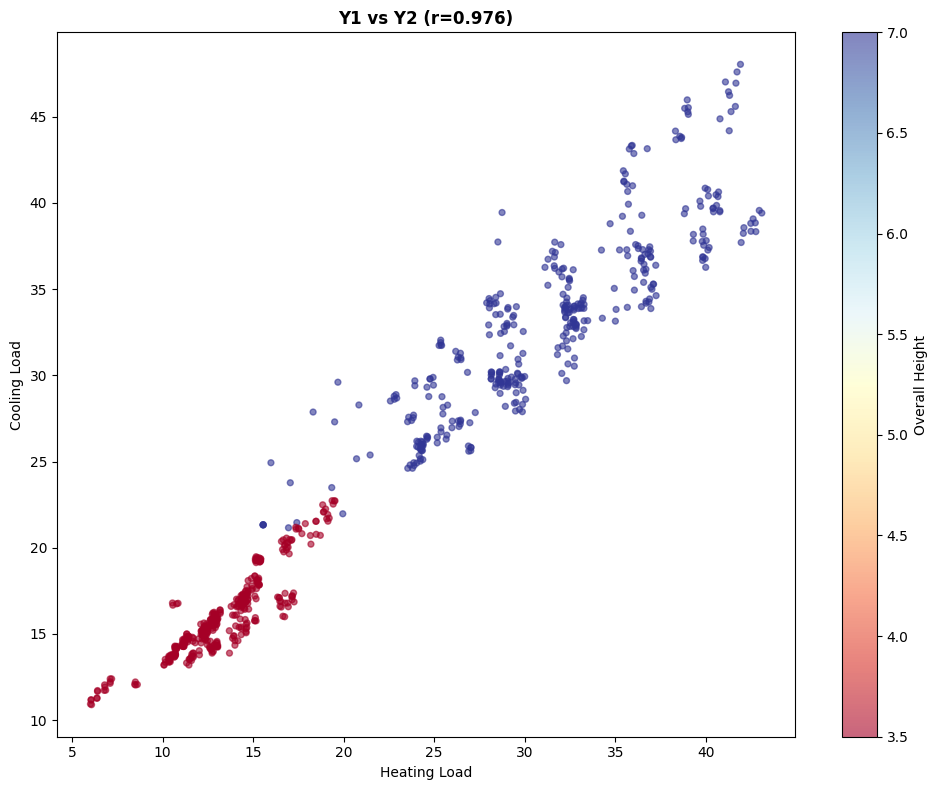

In [ ]:
# Plot 3: Scatter Y1 vs Y2
plt.figure(figsize=(10, 8))
sc = plt.scatter(df_clean['Heating_Load'], df_clean['Cooling_Load'],
                 c=df_clean['Overall_Height'], cmap='RdYlBu', alpha=0.6, s=18)
plt.colorbar(sc, label='Overall Height')
plt.title(f"Y1 vs Y2 (r={df_clean['Heating_Load'].corr(df_clean['Cooling_Load']):.3f})",
              fontweight='bold')
plt.xlabel('Heating Load')
plt.ylabel('Cooling Load')
plt.tight_layout()
plt.show()

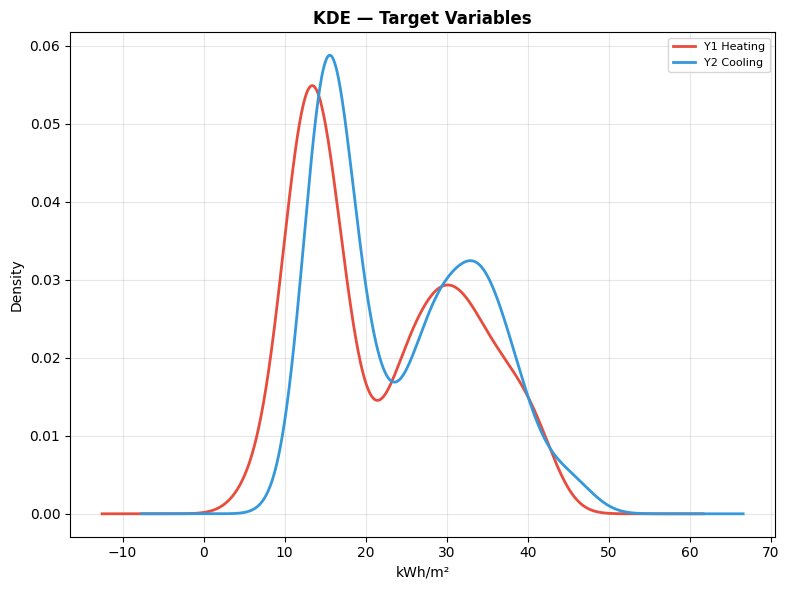

In [ ]:
# Plot 4: KDE Target Variables
plt.figure(figsize=(8, 6))
df_clean['Heating_Load'].plot(kind='kde', color='#E74C3C', linewidth=2, label='Y1 Heating')
df_clean['Cooling_Load'].plot(kind='kde', color='#3498DB', linewidth=2, label='Y2 Cooling')
plt.title('KDE — Target Variables', fontweight='bold')
plt.xlabel('kWh/m²')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

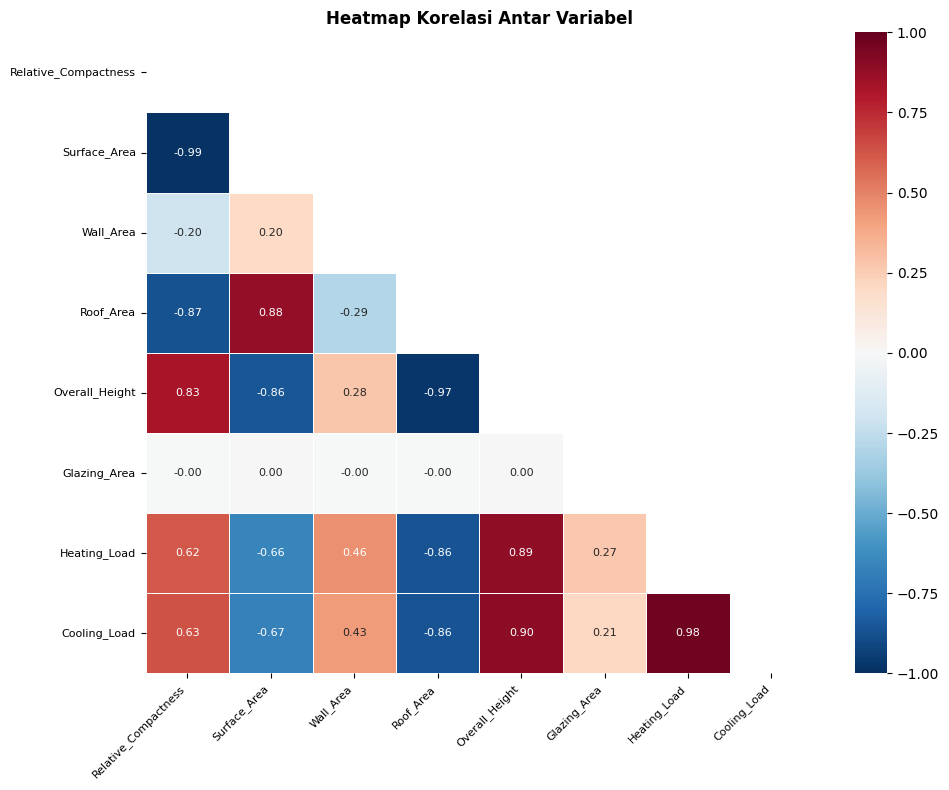

In [ ]:
# Plot 5: Heatmap Korelasi Antar Variabel
plt.figure(figsize=(10, 8))
fitur_corr = [col for col in df_clean.columns if col not in ['Orientation', 'Glazing_Area_Distribution'] and df_clean[col].dtype != 'object']
corr = df_clean[fitur_corr].corr()
mask = np.triu(np.ones_like(corr, dtype=bool)) # Mask for the upper triangle
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            annot_kws={'size': 8}, linewidths=0.4, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Variabel', fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

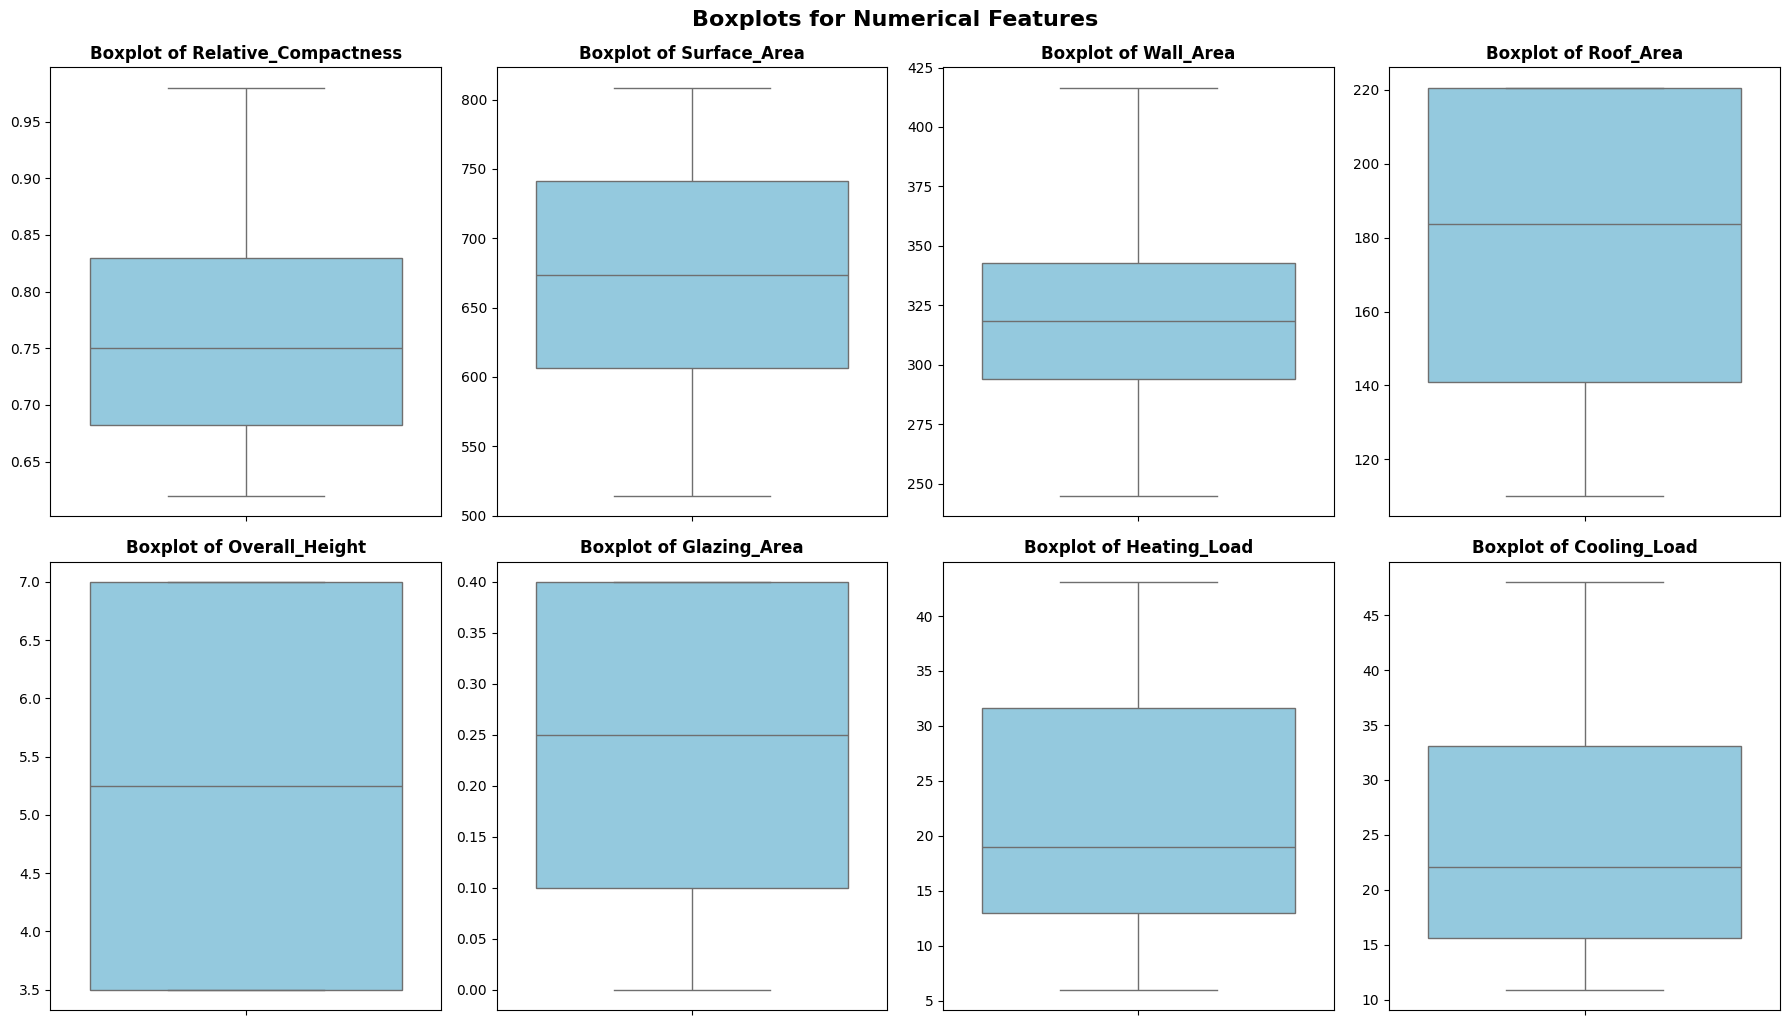

In [ ]:
#Plot 6: Boxplots
plt.figure(figsize=(18, 10))
for i, col in enumerate(fitur_numerik):
    plt.subplot(2, 4, i + 1) # Arrange in 2 rows, 4 columns
    sns.boxplot(y=df_clean[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontweight='bold')
    plt.ylabel('')
plt.tight_layout()
plt.suptitle('Boxplots for Numerical Features', y=1.02, fontsize=16, fontweight='bold')
plt.show()

In [ ]:
#Insight EDA
print(f"  Rata-rata Heating Load : {df['Heating_Load'].mean():.2f} kWh/m²")
print(f"  Rata-rata Cooling Load : {df['Cooling_Load'].mean():.2f} kWh/m²")
print(f"  Korelasi Y1 & Y2       : {df['Heating_Load'].corr(df['Cooling_Load']):.4f}")
print(f"\n  Korelasi fitur dengan Heating Load (Y1):")
for feat in fitur_corr[:-2]:
    r = df[feat].corr(df['Heating_Load'])
    bar = '█' * int(abs(r) * 20)
    print(f"  {feat:<35}: {r:+.4f}  {bar}")

  Rata-rata Heating Load : 22.31 kWh/m²
  Rata-rata Cooling Load : 24.59 kWh/m²
  Korelasi Y1 & Y2       : 0.9759

  Korelasi fitur dengan Heating Load (Y1):
  Relative_Compactness               : +0.6223  ████████████
  Surface_Area                       : -0.6581  █████████████
  Wall_Area                          : +0.4557  █████████
  Roof_Area                          : -0.8618  █████████████████
  Overall_Height                     : +0.8894  █████████████████
  Glazing_Area                       : +0.2698  █████


4. Data Splitting

In [ ]:
split_configs = [
    {'name': '70:30', 'test_size': 0.30, 'label': '70% Train / 30% Test'},
    {'name': '80:20', 'test_size': 0.20, 'label': '80% Train / 20% Test'},
    {'name': '90:10', 'test_size': 0.10, 'label': '90% Train / 10% Test'},
]

splits_y1 = {}
splits_y2 = {}

for cfg in split_configs:
    X_tr, X_te, y1_tr, y1_te = train_test_split(
        X, y1, test_size=cfg['test_size'], random_state=42)
    X_tr2, X_te2, y2_tr, y2_te = train_test_split(
        X, y2, test_size=cfg['test_size'], random_state=42)
    splits_y1[cfg['name']] = (X_tr, X_te, y1_tr, y1_te)
    splits_y2[cfg['name']] = (X_tr2, X_te2, y2_tr, y2_te)
    print(f"\n  Split {cfg['label']}:")
    print(f"    Training set : {X_tr.shape[0]} sampel ({X_tr.shape[0]/len(X)*100:.0f}%)")
    print(f"    Testing set  : {X_te.shape[0]} sampel ({X_te.shape[0]/len(X)*100:.0f}%)")


  Split 70% Train / 30% Test:
    Training set : 537 sampel (70%)
    Testing set  : 231 sampel (30%)

  Split 80% Train / 20% Test:
    Training set : 614 sampel (80%)
    Testing set  : 154 sampel (20%)

  Split 90% Train / 10% Test:
    Training set : 691 sampel (90%)
    Testing set  : 77 sampel (10%)


5. Model Building

In [ ]:
def build_models():
    models = {
        'Linear Regression': Pipeline([
            ('scaler', StandardScaler()),
            ('model', Ridge(alpha=1.0))
        ]),
        'Random Forest': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(
                n_estimators=100, max_depth=None,
                min_samples_split=2, random_state=42, n_jobs=-1))
        ]),
        'SVR': Pipeline([
            ('scaler', StandardScaler()),
            ('model', SVR(C=1.0, kernel='rbf', epsilon=0.1, gamma='scale'))
        ]),
    }
    return models

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'y_pred': y_pred,
            'y_test': y_test, 'model': model}

# Evaluasi semua model pada split — sebelum tuning
print("\n  [Y1 - Heating Load] Sebelum Tuning:")
results_before_y1 = {}
for split_name, (X_tr, X_te, y_tr, y_te) in splits_y1.items():
    results_before_y1[split_name] = {}
    for model_name, model in build_models().items():
        res = evaluate_model(model, X_tr, X_te, y_tr, y_te)
        results_before_y1[split_name][model_name] = res
        print(f"    [{split_name}] {model_name:<22} RMSE={res['RMSE']:.4f}  MAE={res['MAE']:.4f}  R²={res['R²']:.4f}")

print("\n  [Y2 - Cooling Load] Sebelum Tuning:")
results_before_y2 = {}
for split_name, (X_tr, X_te, y_tr, y_te) in splits_y2.items():
    results_before_y2[split_name] = {}
    for model_name, model in build_models().items():
        res = evaluate_model(model, X_tr, X_te, y_tr, y_te)
        results_before_y2[split_name][model_name] = res
        print(f"    [{split_name}] {model_name:<22} RMSE={res['RMSE']:.4f}  MAE={res['MAE']:.4f}  R²={res['R²']:.4f}")


  [Y1 - Heating Load] Sebelum Tuning:
    [70:30] Linear Regression      RMSE=2.8889  MAE=2.1035  R²=0.9177
    [70:30] Random Forest          RMSE=0.5098  MAE=0.3457  R²=0.9974
    [70:30] SVR                    RMSE=3.1036  MAE=2.0416  R²=0.9050
    [80:20] Linear Regression      RMSE=2.8855  MAE=2.0745  R²=0.9201
    [80:20] Random Forest          RMSE=0.5261  MAE=0.3591  R²=0.9973
    [80:20] SVR                    RMSE=3.1132  MAE=1.9900  R²=0.9070
    [90:10] Linear Regression      RMSE=3.0848  MAE=2.3000  R²=0.9133
    [90:10] Random Forest          RMSE=0.4727  MAE=0.3106  R²=0.9980
    [90:10] SVR                    RMSE=3.1910  MAE=2.0670  R²=0.9072

  [Y2 - Cooling Load] Sebelum Tuning:
    [70:30] Linear Regression      RMSE=3.2065  MAE=2.2883  R²=0.8859
    [70:30] Random Forest          RMSE=1.8678  MAE=1.1658  R²=0.9613
    [70:30] SVR                    RMSE=3.4952  MAE=2.2971  R²=0.8645
    [80:20] Linear Regression      RMSE=3.1283  MAE=2.1849  R²=0.8944
    [80:20] 

6. Hyperparameter Tuning

In [ ]:
param_grids = {
    'Linear Regression': {
        'param_grid': {'model__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', Ridge())])
    },
    'Random Forest': {
        'param_grid': {
            'model__n_estimators'     : [50, 100, 200],
            'model__max_depth'        : [None, 10, 20],
            'model__min_samples_split': [2, 5, 10],
        },
        'pipeline': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
        ])
    },
    'SVR': {
        'param_grid': {
            'model__C'      : [0.1, 1.0, 10.0, 100.0],
            'model__kernel' : ['rbf', 'linear'],
            'model__epsilon': [0.01, 0.1, 0.5],
            'model__gamma'  : ['scale', 'auto'],
        },
        'pipeline': Pipeline([('scaler', StandardScaler()), ('model', SVR())])
    },
}

# best_tuned_models[split_name][model_name] = fitted best_estimator
best_tuned_y1 = {s: {} for s in ['70:30', '80:20', '90:10']}
best_tuned_y2 = {s: {} for s in ['70:30', '80:20', '90:10']}
best_params_y1 = {s: {} for s in ['70:30', '80:20', '90:10']}
best_params_y2 = {s: {} for s in ['70:30', '80:20', '90:10']}

for split_name in ['70:30', '80:20', '90:10']:
    X_tr, X_te, y_tr, y_te   = splits_y1[split_name]
    X_tr2, X_te2, y_tr2, y_te2 = splits_y2[split_name]

    print(f"\n  ══ Split {split_name} ══")

    for model_name, cfg in param_grids.items():
        # --- Tuning Y1 ---
        gs1 = GridSearchCV(clone(cfg['pipeline']), cfg['param_grid'],
                           cv=5, scoring='neg_root_mean_squared_error',
                           n_jobs=-1, verbose=0)
        gs1.fit(X_tr, y_tr)
        best_tuned_y1[split_name][model_name] = gs1.best_estimator_
        best_params_y1[split_name][model_name] = gs1.best_params_

        # --- Tuning Y2 ---
        gs2 = GridSearchCV(clone(cfg['pipeline']), cfg['param_grid'],
                           cv=5, scoring='neg_root_mean_squared_error',
                           n_jobs=-1, verbose=0)
        gs2.fit(X_tr2, y_tr2)
        best_tuned_y2[split_name][model_name] = gs2.best_estimator_
        best_params_y2[split_name][model_name] = gs2.best_params_

        print(f"    {model_name:<22} | Y1 Best CV RMSE={-gs1.best_score_:.4f}  params={gs1.best_params_}")
        print(f"    {' ':<22} | Y2 Best CV RMSE={-gs2.best_score_:.4f}  params={gs2.best_params_}")


  ══ Split 70:30 ══
    Linear Regression      | Y1 Best CV RMSE=2.8210  params={'model__alpha': 0.1}
                           | Y2 Best CV RMSE=3.2063  params={'model__alpha': 0.1}
    Random Forest          | Y1 Best CV RMSE=0.5618  params={'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
                           | Y2 Best CV RMSE=1.8499  params={'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
    SVR                    | Y1 Best CV RMSE=2.6609  params={'model__C': 10.0, 'model__epsilon': 0.01, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
                           | Y2 Best CV RMSE=2.9741  params={'model__C': 10.0, 'model__epsilon': 0.5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}

  ══ Split 80:20 ══
    Linear Regression      | Y1 Best CV RMSE=2.8264  params={'model__alpha': 0.1}
                           | Y2 Best CV RMSE=3.2303  params={'model__alpha': 0.1}
    Random Forest          | Y1 Best CV

7. Model Evaluation

In [ ]:
results_after_y1 = {s: {} for s in ['70:30', '80:20', '90:10']}
results_after_y2 = {s: {} for s in ['70:30', '80:20', '90:10']}

for split_name in ['70:30', '80:20', '90:10']:
    X_tr, X_te, y_tr, y_te     = splits_y1[split_name]
    X_tr2, X_te2, y_tr2, y_te2 = splits_y2[split_name]

    for model_name in best_tuned_y1[split_name]:
        # Y1
        y1_pred = best_tuned_y1[split_name][model_name].predict(X_te)
        results_after_y1[split_name][model_name] = {
            'RMSE'  : np.sqrt(mean_squared_error(y_te, y1_pred)),
            'MAE'   : mean_absolute_error(y_te, y1_pred),
            'R²'    : r2_score(y_te, y1_pred),
            'y_pred': y1_pred,
            'y_test': y_te
        }
        # Y2
        y2_pred = best_tuned_y2[split_name][model_name].predict(X_te2)
        results_after_y2[split_name][model_name] = {
            'RMSE'  : np.sqrt(mean_squared_error(y_te2, y2_pred)),
            'MAE'   : mean_absolute_error(y_te2, y2_pred),
            'R²'    : r2_score(y_te2, y2_pred),
            'y_pred': y2_pred,
            'y_test': y_te2
        }

# Tabel evaluasi
model_keys   = ['Linear Regression', 'Random Forest', 'SVR']

print("\n  [Y1 - Heating Load] Hasil Evaluasi Setelah Tuning:")
print(f"  {'Split':<8} {'Model':<24} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("  " + "-" * 60)
for split_name, models in results_after_y1.items():
    for model_name, res in models.items():
        print(f"  {split_name:<8} {model_name:<24} {res['RMSE']:>8.4f} {res['MAE']:>8.4f} {res['R²']:>8.4f}")
    print("  " + "-" * 60)

print("\n  [Y2 - Cooling Load] Hasil Evaluasi Setelah Tuning:")
print(f"  {'Split':<8} {'Model':<24} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("  " + "-" * 60)
for split_name, models in results_after_y2.items():
    for model_name, res in models.items():
        print(f"  {split_name:<8} {model_name:<24} {res['RMSE']:>8.4f} {res['MAE']:>8.4f} {res['R²']:>8.4f}")
    print("  " + "-" * 60)




  [Y1 - Heating Load] Hasil Evaluasi Setelah Tuning:
  Split    Model                        RMSE      MAE       R²
  ------------------------------------------------------------
  70:30    Linear Regression          2.8874   2.1017   0.9178
  70:30    Random Forest              0.5076   0.3446   0.9975
  70:30    SVR                        2.6481   1.5717   0.9308
  ------------------------------------------------------------
  80:20    Linear Regression          2.8736   2.0609   0.9208
  80:20    Random Forest              0.5240   0.3577   0.9974
  80:20    SVR                        2.5664   1.4448   0.9368
  ------------------------------------------------------------
  90:10    Linear Regression          3.0813   2.2986   0.9135
  90:10    Random Forest              0.4779   0.3170   0.9979
  90:10    SVR                        2.7766   1.6758   0.9297
  ------------------------------------------------------------

  [Y2 - Cooling Load] Hasil Evaluasi Setelah Tuning:
  Split   

In [ ]:
# 5-Fold Cross-Validation
print("\n  Cross-Validation (5-Fold):")
cv_results_y1 = {s: {} for s in ['70:30', '80:20', '90:10']}
cv_results_y2 = {s: {} for s in ['70:30', '80:20', '90:10']}

for split_name in ['70:30', '80:20', '90:10']:
    X_tr, X_te, y_tr, y_te     = splits_y1[split_name]
    X_tr2, X_te2, y_tr2, y_te2 = splits_y2[split_name]
    print(f"\n  Split {split_name}:")
    for model_name in model_keys:
        m1 = clone(best_tuned_y1[split_name][model_name])
        cv1 = cross_val_score(m1, X_tr, y_tr, cv=5, scoring='r2')
        cv_results_y1[split_name][model_name] = cv1
        m2 = clone(best_tuned_y2[split_name][model_name])
        cv2 = cross_val_score(m2, X_tr2, y_tr2, cv=5, scoring='r2')
        cv_results_y2[split_name][model_name] = cv2
        print(f"    {model_name:<22} Y1 R²={cv1.mean():.4f}±{cv1.std():.4f}   "
              f"Y2 R²={cv2.mean():.4f}±{cv2.std():.4f}")



  Cross-Validation (5-Fold):

  Split 70:30:
    Linear Regression      Y1 R²=0.9203±0.0076   Y2 R²=0.8837±0.0215
    Random Forest          Y1 R²=0.9967±0.0009   Y2 R²=0.9611±0.0061
    SVR                    Y1 R²=0.9290±0.0102   Y2 R²=0.9002±0.0169

  Split 80:20:
    Linear Regression      Y1 R²=0.9205±0.0030   Y2 R²=0.8832±0.0071
    Random Forest          Y1 R²=0.9971±0.0007   Y2 R²=0.9648±0.0083
    SVR                    Y1 R²=0.9328±0.0057   Y2 R²=0.8996±0.0094

  Split 90:10:
    Linear Regression      Y1 R²=0.9224±0.0083   Y2 R²=0.8871±0.0179
    Random Forest          Y1 R²=0.9973±0.0003   Y2 R²=0.9628±0.0027
    SVR                    Y1 R²=0.9388±0.0102   Y2 R²=0.9120±0.0104


8. Model Comparison & Visualisasi

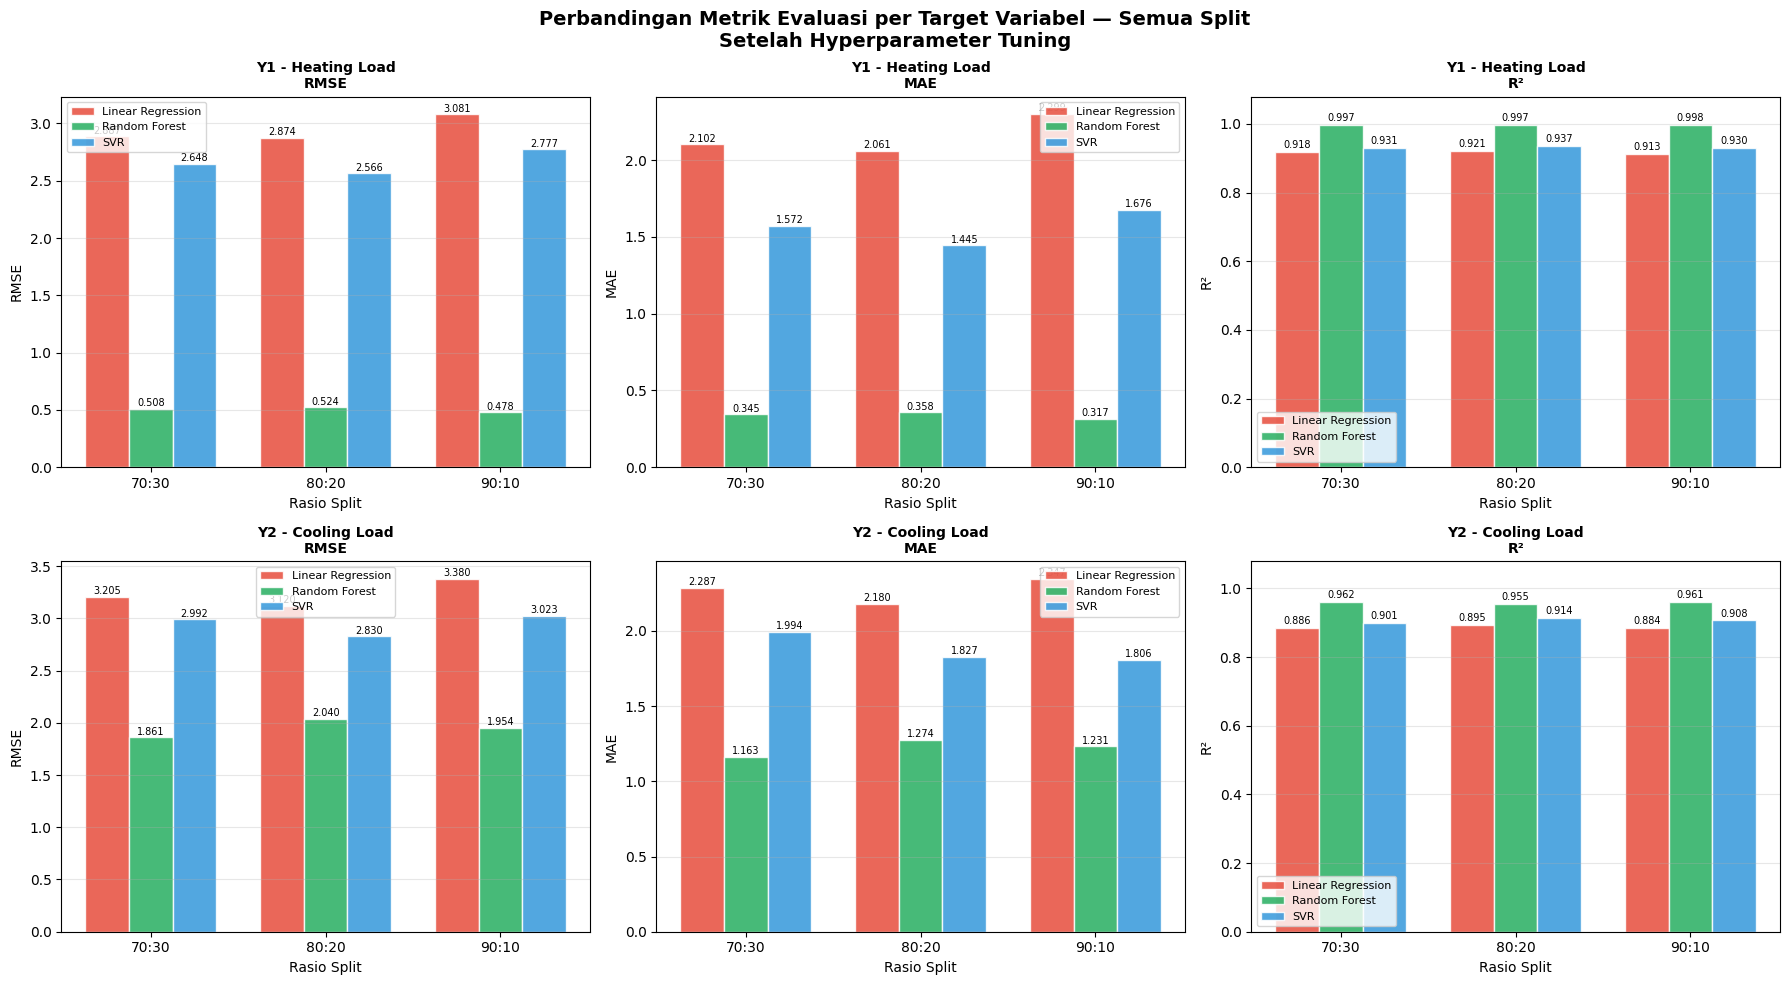

In [ ]:
split_labels = ['70:30', '80:20', '90:10']
model_labels = ['Linear Regression', 'Random Forest', 'SVR']
colors_model = ['#E74C3C', '#27AE60', '#3498DB']

targets = [
    ('Y1 - Heating Load', results_after_y1),
    ('Y2 - Cooling Load', results_after_y2),
]

#8.1 Perbandingan Metrik per Target per Split
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 10))
fig3.suptitle('Perbandingan Metrik Evaluasi per Target Variabel — Semua Split\n'
              'Setelah Hyperparameter Tuning',
              fontsize=14, fontweight='bold')
metrics = ['RMSE', 'MAE', 'R²']
for row_idx, (tgt_label, res_dict) in enumerate(targets):
    for col_idx, metric in enumerate(metrics):
        ax = axes3[row_idx, col_idx]
        x = np.arange(len(split_labels))
        width = 0.25
        for j, (ml, col) in enumerate(zip(model_labels, colors_model)):
            vals = [res_dict[s][ml][metric] for s in split_labels]
            bars = ax.bar(x + j * width, vals, width, label=ml,
                          color=col, alpha=0.85, edgecolor='white')
            for bar, v in zip(bars, vals):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=7)
        ax.set_title(f'{tgt_label}\n{metric}', fontweight='bold', fontsize=10)
        ax.set_xticks(x + width)
        ax.set_xticklabels(split_labels)
        ax.set_xlabel('Rasio Split')
        ax.set_ylabel(metric)
        if metric == 'R²':
            ax.set_ylim(0, 1.08)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

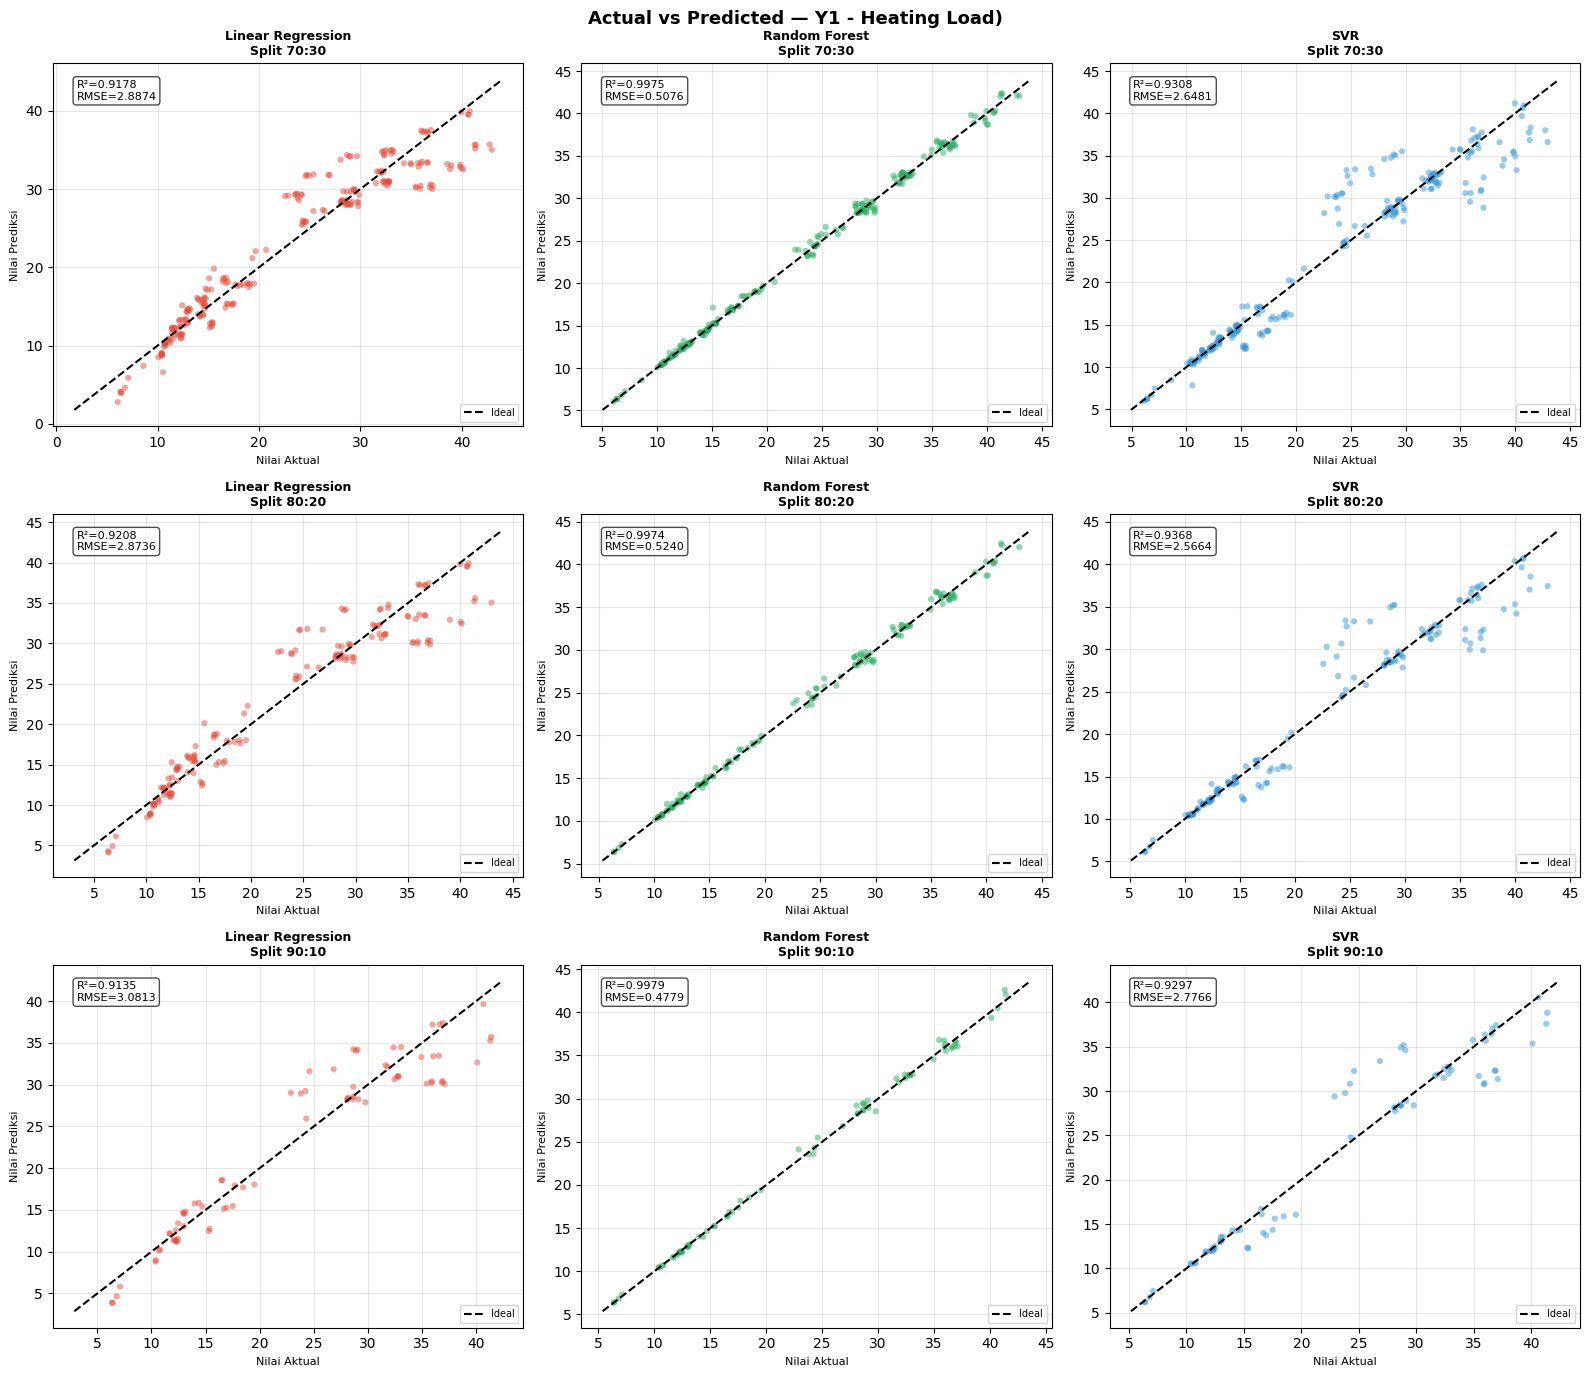

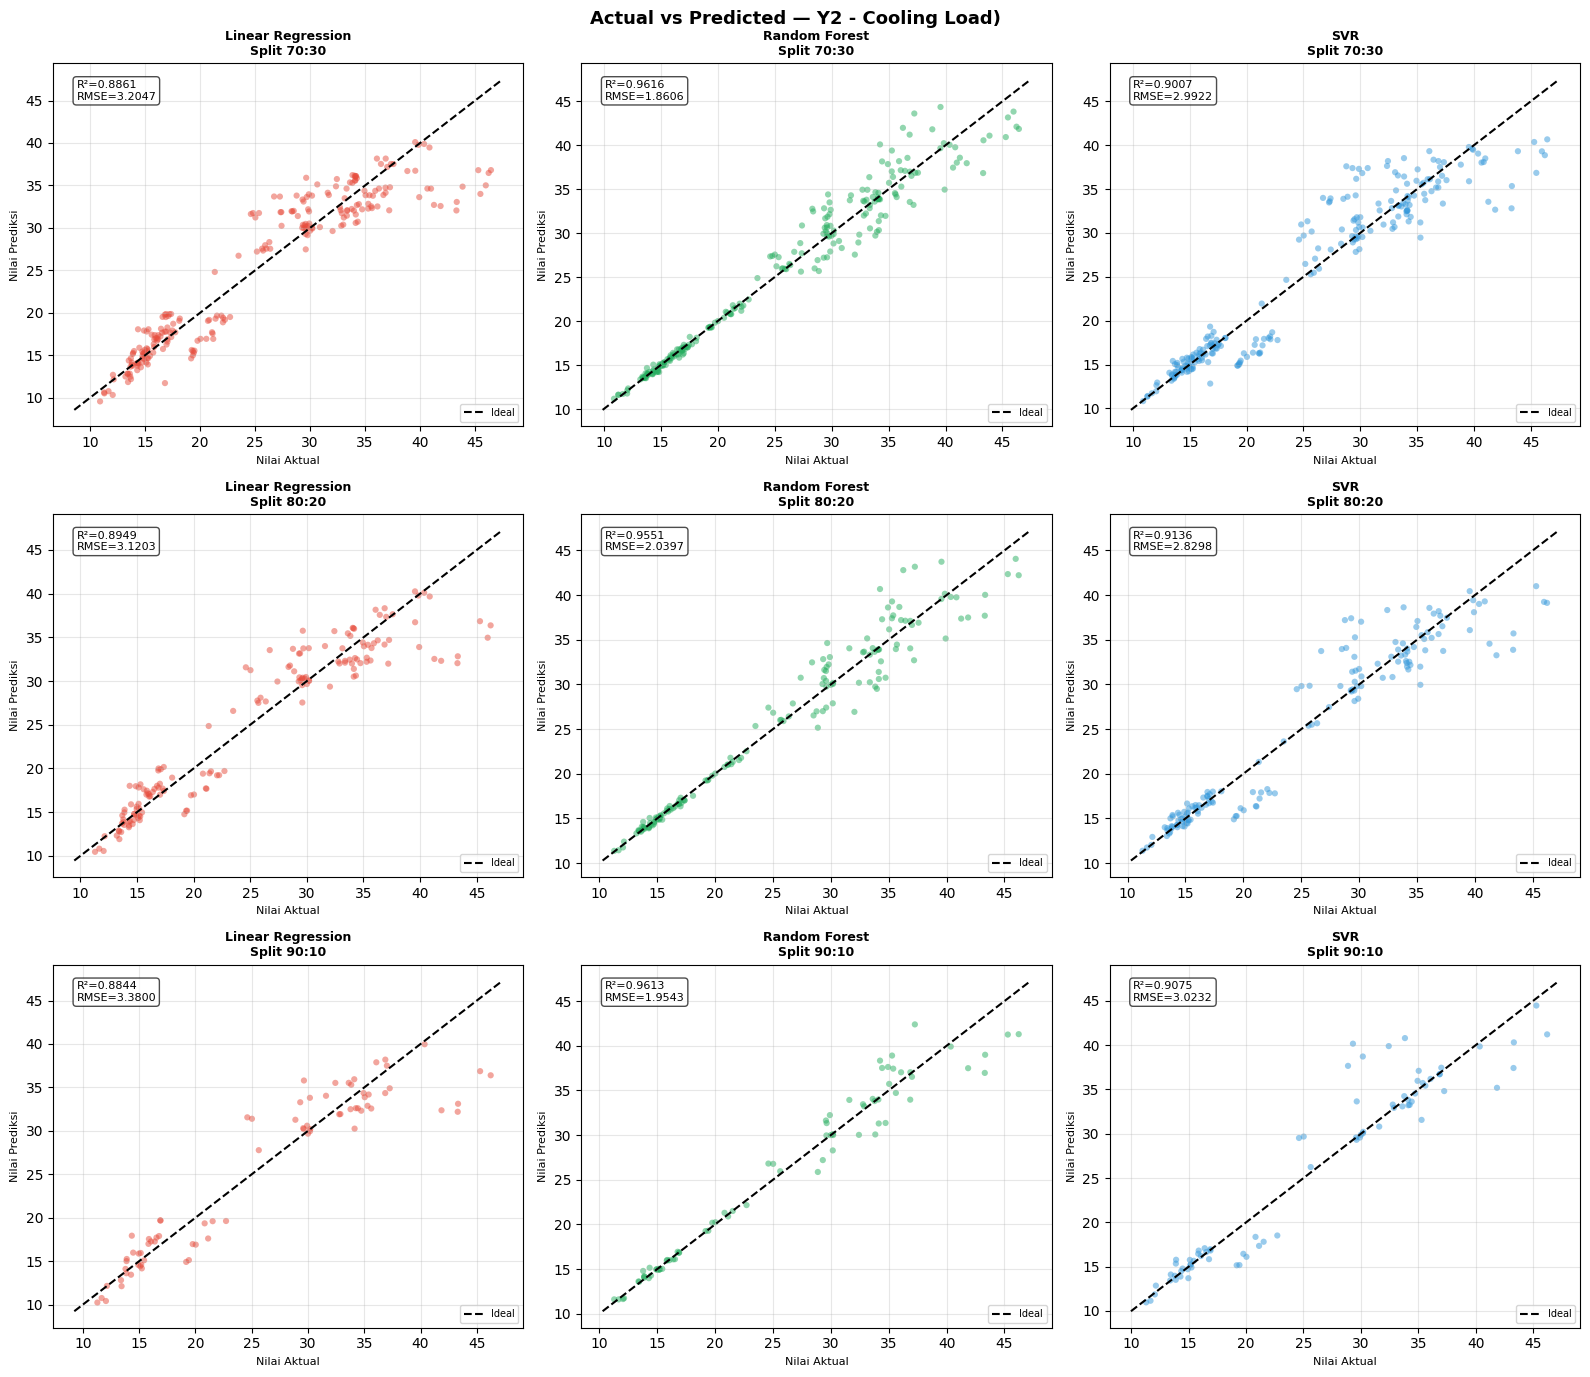

In [ ]:
#8.2 Actual vs Predicted
for tgt_label, res_dict, tgt_short in [
        ('Y1 - Heating Load', results_after_y1, 'Y1'),
        ('Y2 - Cooling Load', results_after_y2, 'Y2')]:
    fig_avp, axes_avp = plt.subplots(3, 3, figsize=(16, 14))
    fig_avp.suptitle(f'Actual vs Predicted — {tgt_label})',
                     fontsize=13, fontweight='bold')
    for row_idx, split_name in enumerate(split_labels):
        for col_idx, (ml, col) in enumerate(zip(model_labels, colors_model)):
            ax = axes_avp[row_idx, col_idx]
            y_test = res_dict[split_name][ml]['y_test']
            y_pred = res_dict[split_name][ml]['y_pred']
            ax.scatter(y_test, y_pred, alpha=0.5, s=20, color=col, edgecolors='none')
            lims = [min(float(y_test.min()), float(y_pred.min())) - 1,
                    max(float(y_test.max()), float(y_pred.max())) + 1]
            ax.plot(lims, lims, 'k--', linewidth=1.5, label='Ideal')
            r2_v  = res_dict[split_name][ml]['R²']
            rmse_v = res_dict[split_name][ml]['RMSE']
            ax.set_title(f'{ml}\nSplit {split_name}', fontweight='bold', fontsize=9)
            ax.set_xlabel('Nilai Aktual', fontsize=8)
            ax.set_ylabel('Nilai Prediksi', fontsize=8)
            ax.text(0.05, 0.90, f'R²={r2_v:.4f}\nRMSE={rmse_v:.4f}',
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
    plt.tight_layout()

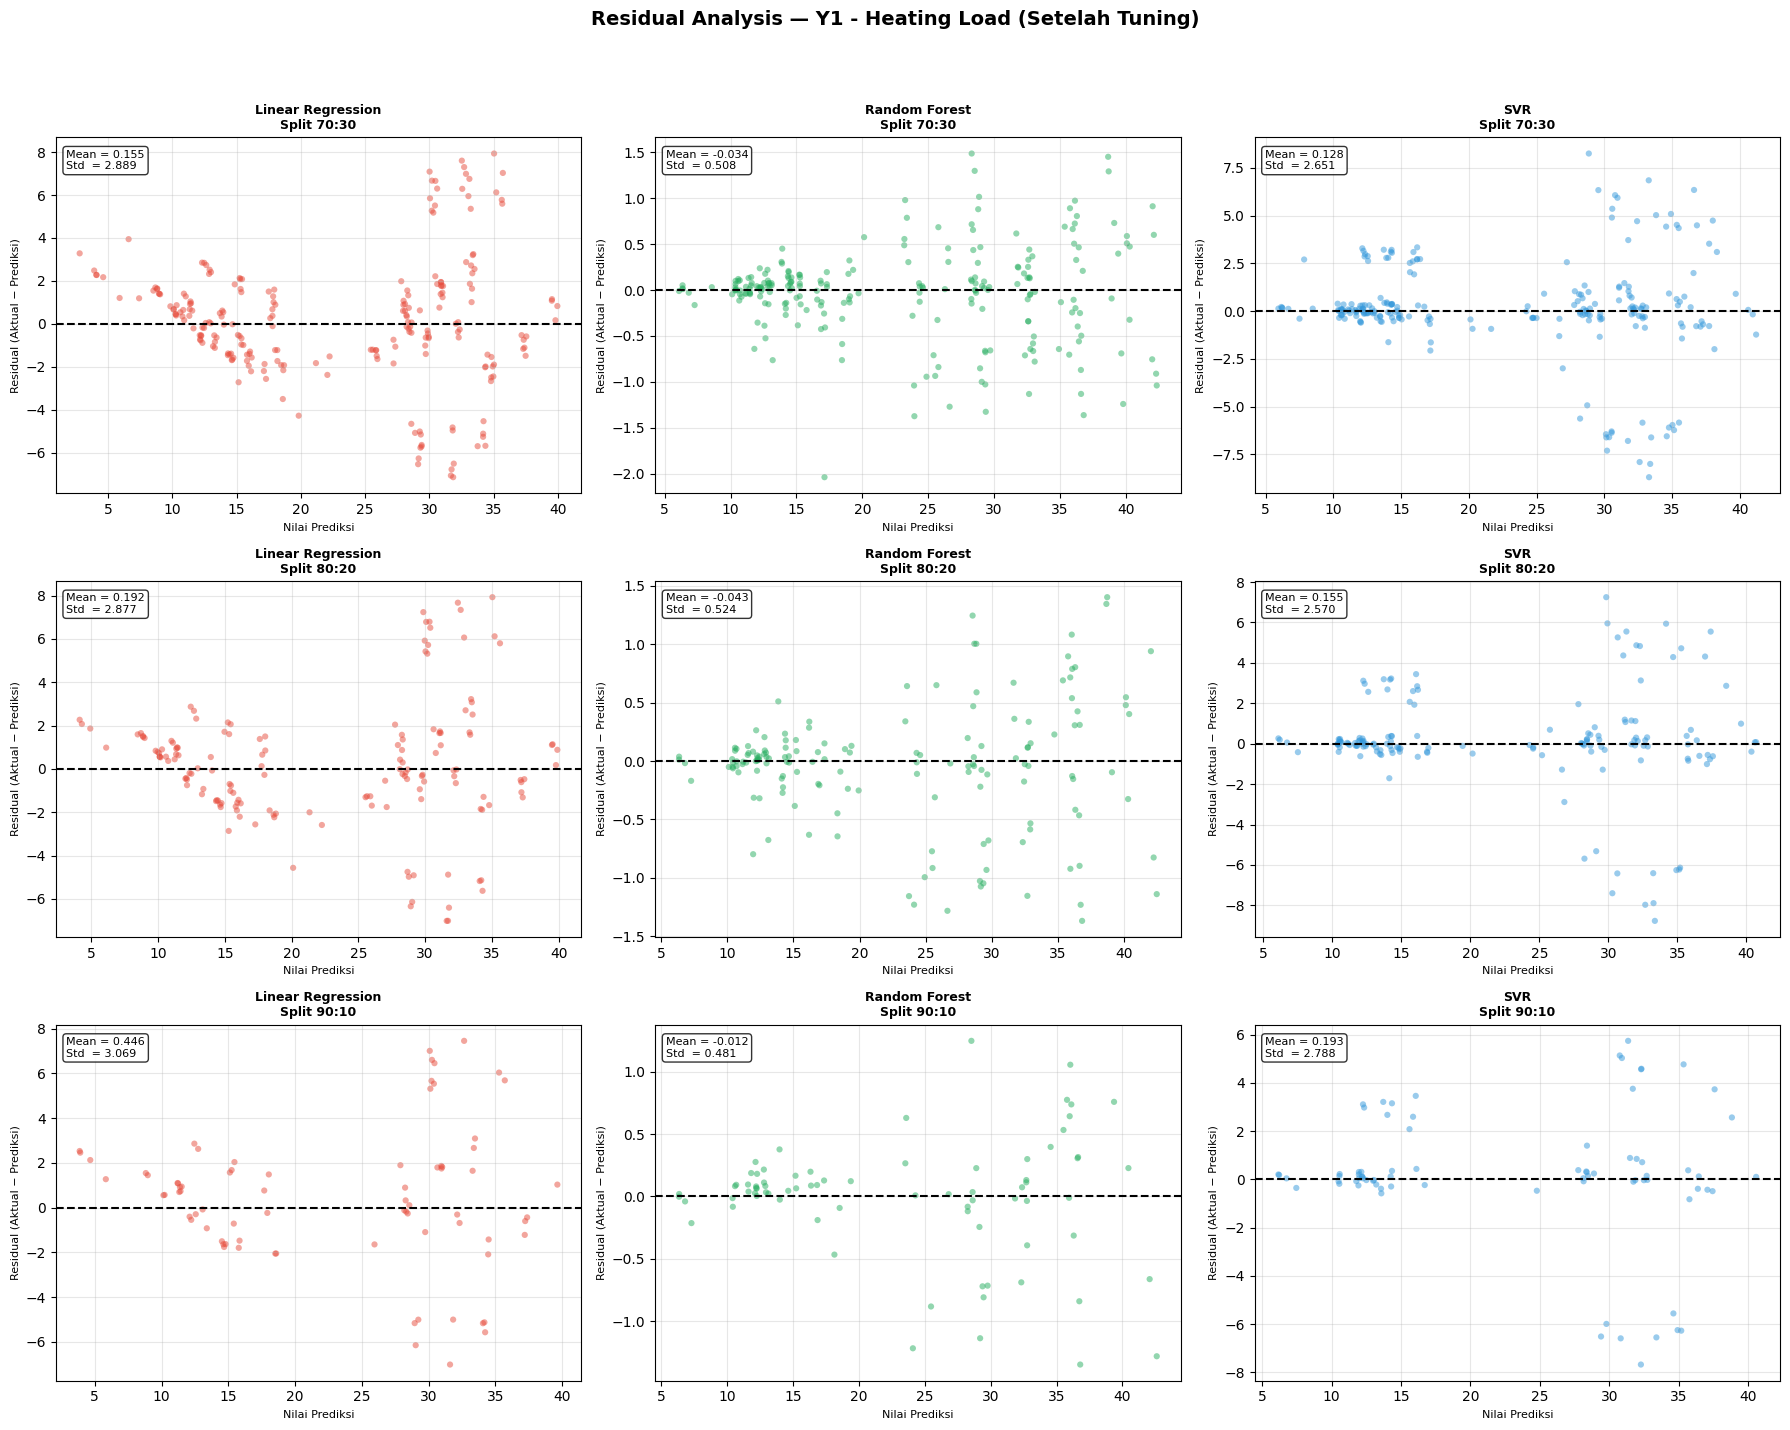

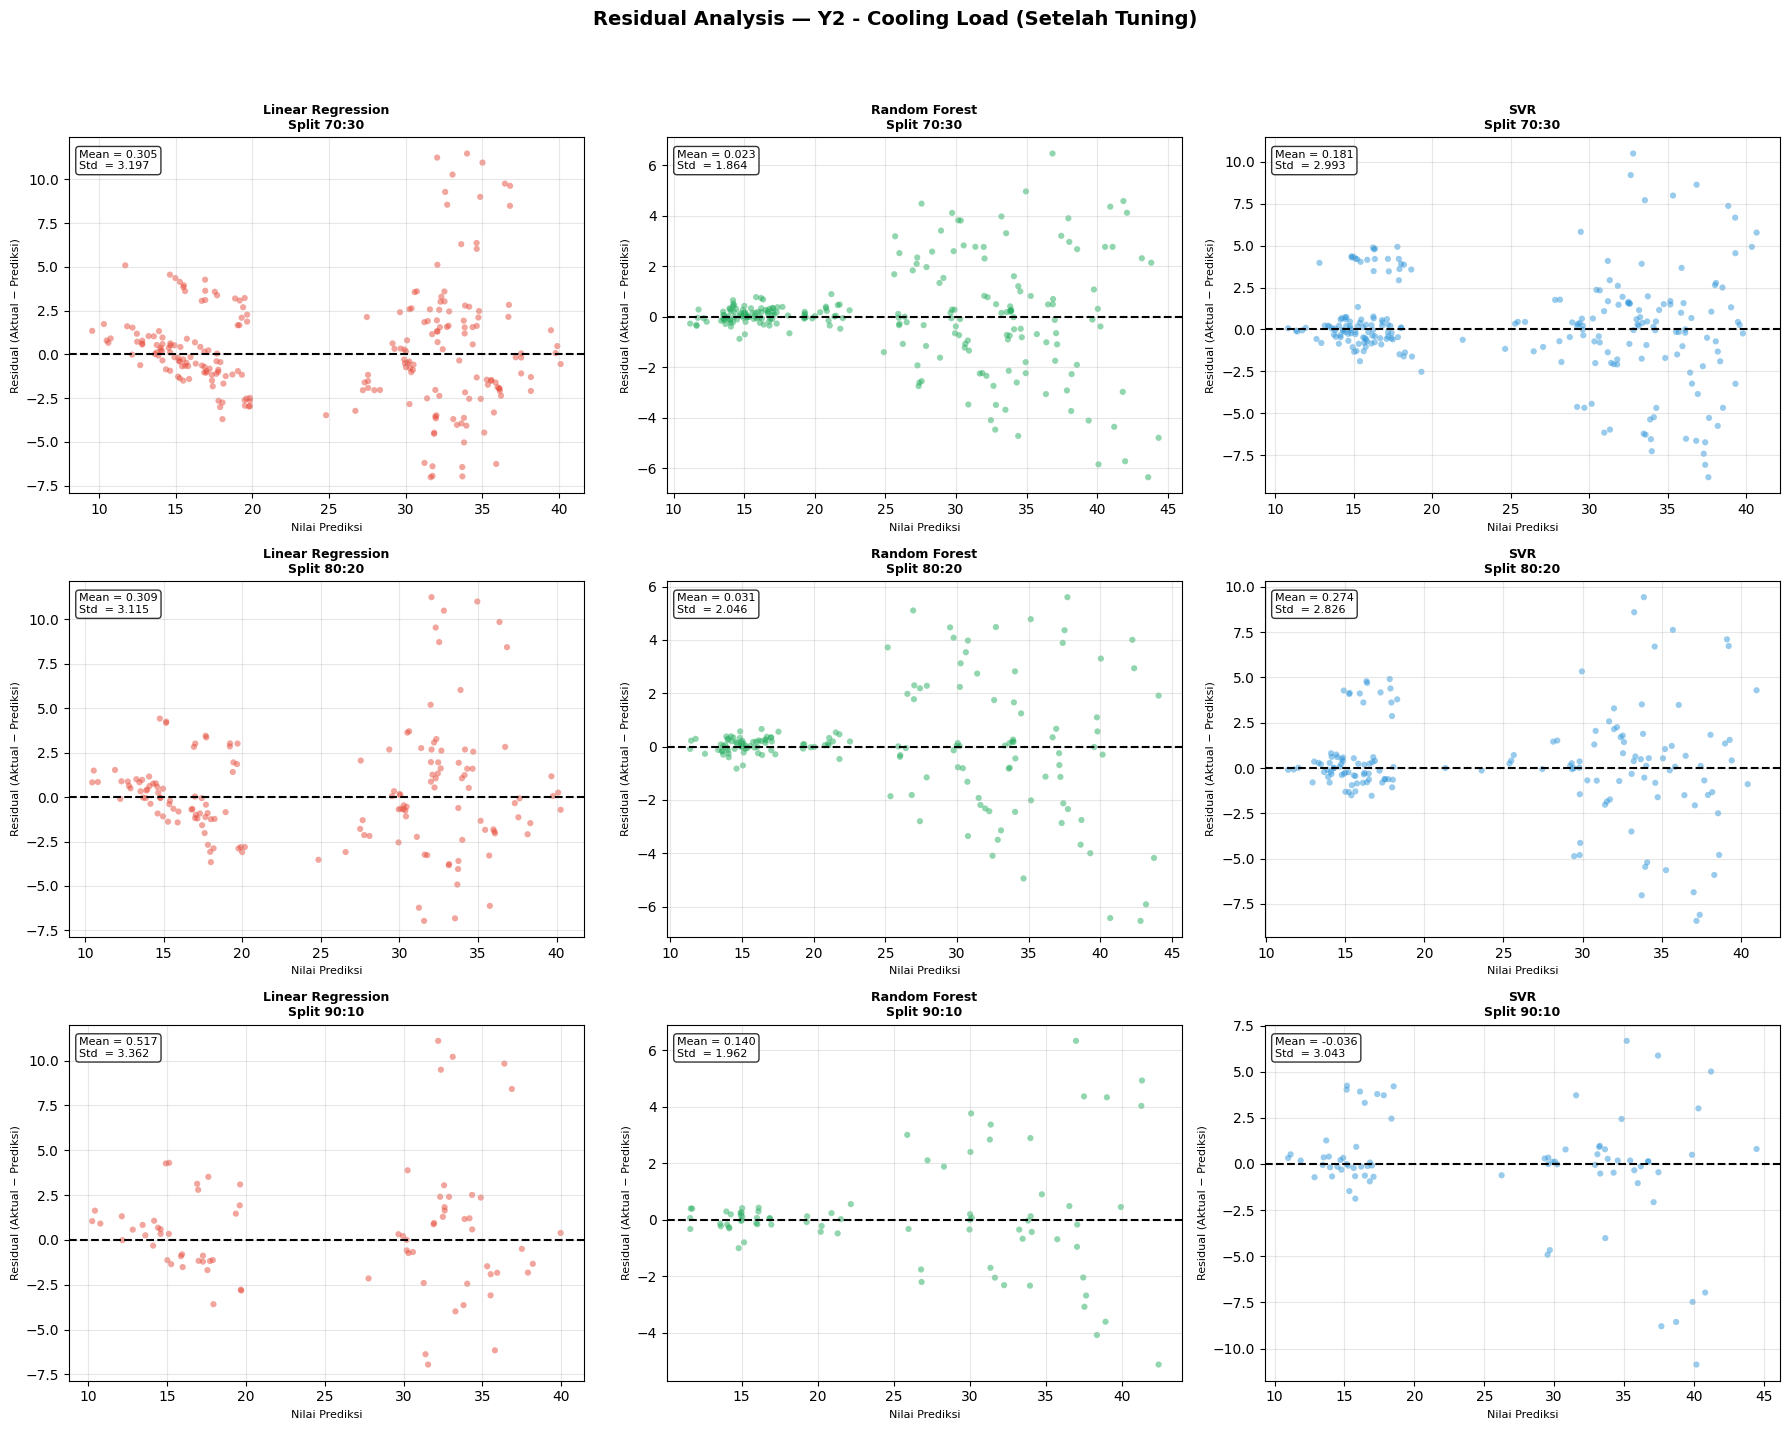

In [ ]:
# 8.5 Residual Analysis
targets_for_residual_analysis = [
    ('Y1 - Heating Load', results_after_y1, 'y1'),
    ('Y2 - Cooling Load', results_after_y2, 'y2')
]

model_names = model_labels # ['Linear Regression', 'Random Forest', 'SVR']
model_color_map = {name: colors_model[idx] for idx, name in enumerate(model_labels)}

for target_label, results_dict, target_key in targets_for_residual_analysis:
    fig_res, axes_res = plt.subplots(len(split_labels), len(model_names), figsize=(18, 15))
    fig_res.suptitle(f'Residual Analysis — {target_label} (Setelah Tuning)',
                     fontsize=14, fontweight='bold')

    for row_idx, split_name in enumerate(split_labels):
        for col_idx, model_name in enumerate(model_names):
            ax = axes_res[row_idx, col_idx]

            y_test = results_dict[split_name][model_name]['y_test']
            y_pred = results_dict[split_name][model_name]['y_pred']
            residuals = y_test - y_pred

            ax.scatter(y_pred, residuals, alpha=0.5, s=20,
                       color=model_color_map[model_name],
                       edgecolors='none')
            ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
            ax.set_title(f'{model_name}\nSplit {split_name}', fontweight='bold', fontsize=9)
            ax.set_xlabel('Nilai Prediksi', fontsize=8)
            ax.set_ylabel('Residual (Aktual − Prediksi)', fontsize=8)
            ax.text(0.02, 0.91,
                    f'Mean = {residuals.mean():.3f}\nStd  = {residuals.std():.3f}',
                    transform=ax.transAxes, fontsize=8,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
            ax.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

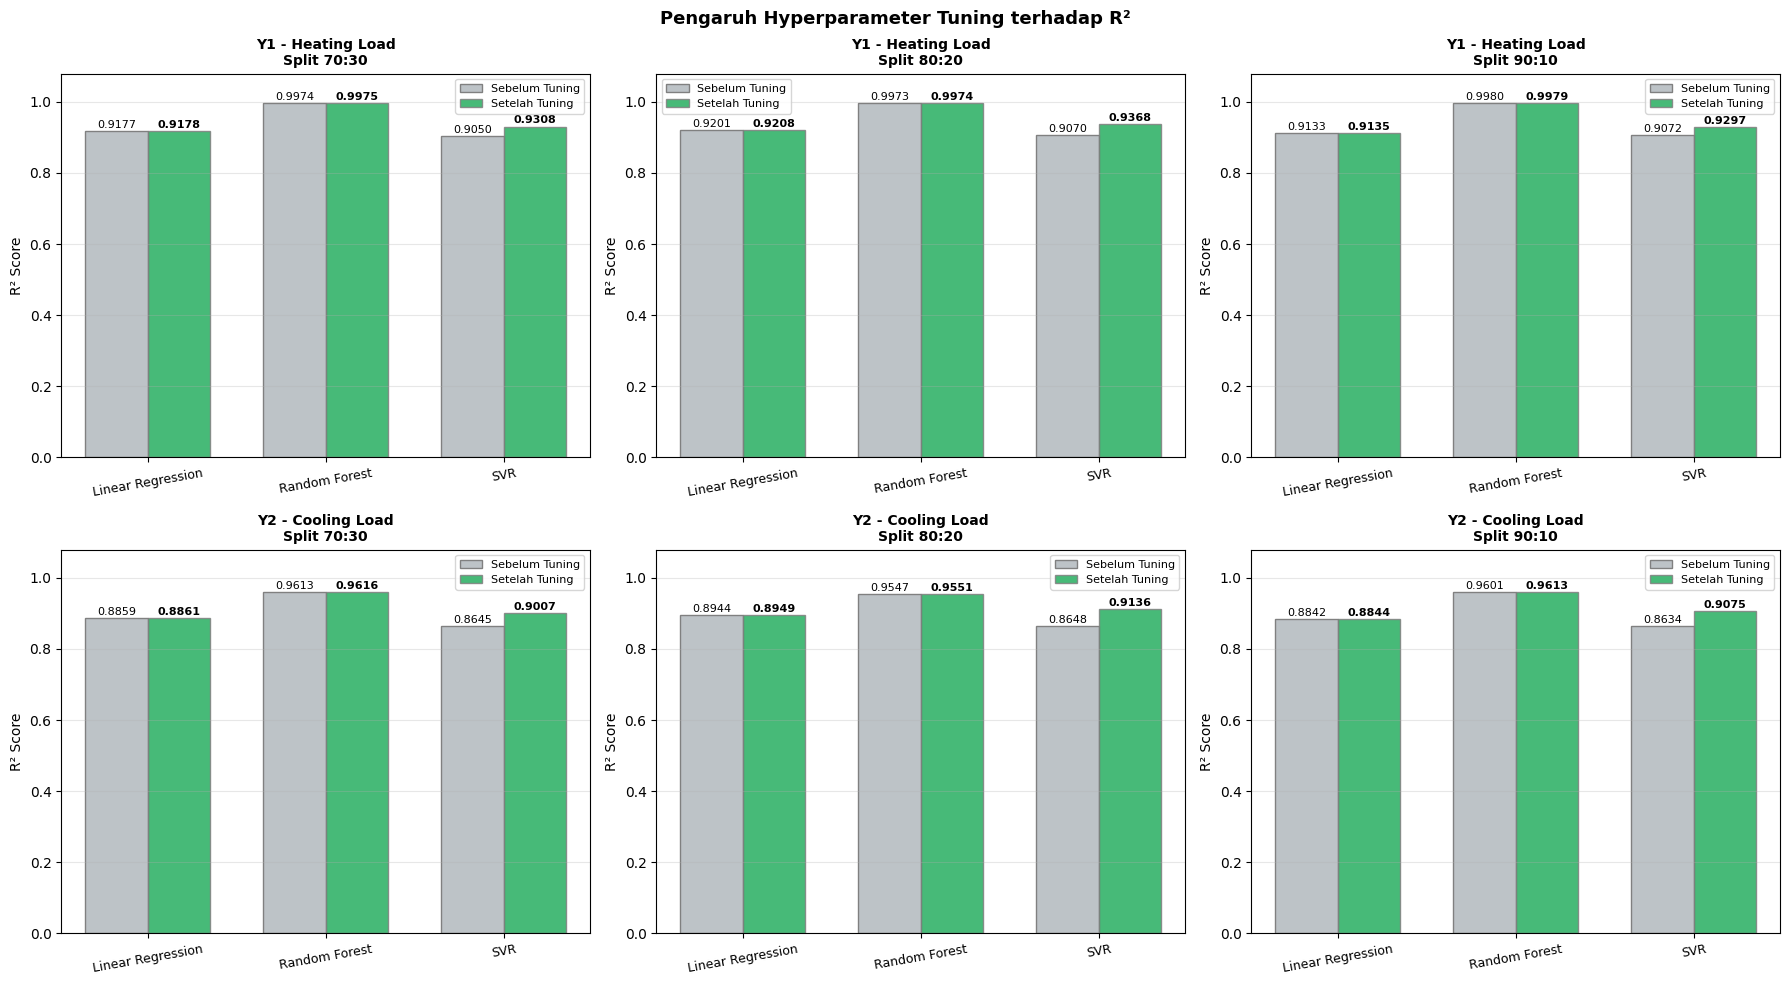

In [ ]:
#8.3 Sebelum vs Sesudah Tuning
fig5, axes5 = plt.subplots(2, 3, figsize=(18, 10))
fig5.suptitle('Pengaruh Hyperparameter Tuning terhadap R²',
              fontsize=13, fontweight='bold')

for row_idx, (tgt_label, before_dict, after_dict) in enumerate([
        ('Y1 - Heating Load', results_before_y1, results_after_y1),
        ('Y2 - Cooling Load', results_before_y2, results_after_y2)]):
    for col_idx, split_name in enumerate(split_labels):
        ax = axes5[row_idx, col_idx]
        x = np.arange(len(model_labels))
        w = 0.35
        r2_before = [before_dict[split_name][ml]['R²'] for ml in model_labels]
        r2_after  = [after_dict[split_name][ml]['R²']  for ml in model_labels]
        b1 = ax.bar(x - w/2, r2_before, w, label='Sebelum Tuning',
                    color='#BDC3C7', edgecolor='gray')
        b2 = ax.bar(x + w/2, r2_after,  w, label='Setelah Tuning',
                    color='#27AE60', edgecolor='gray', alpha=0.85)
        for bar, v in zip(b1, r2_before):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=8)
        for bar, v in zip(b2, r2_after):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                    f'{v:.4f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.set_title(f'{tgt_label}\nSplit {split_name}', fontweight='bold', fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(model_labels, rotation=10, fontsize=9)
        ax.set_ylabel('R² Score')
        ax.set_ylim(0, 1.08)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3)

plt.tight_layout()

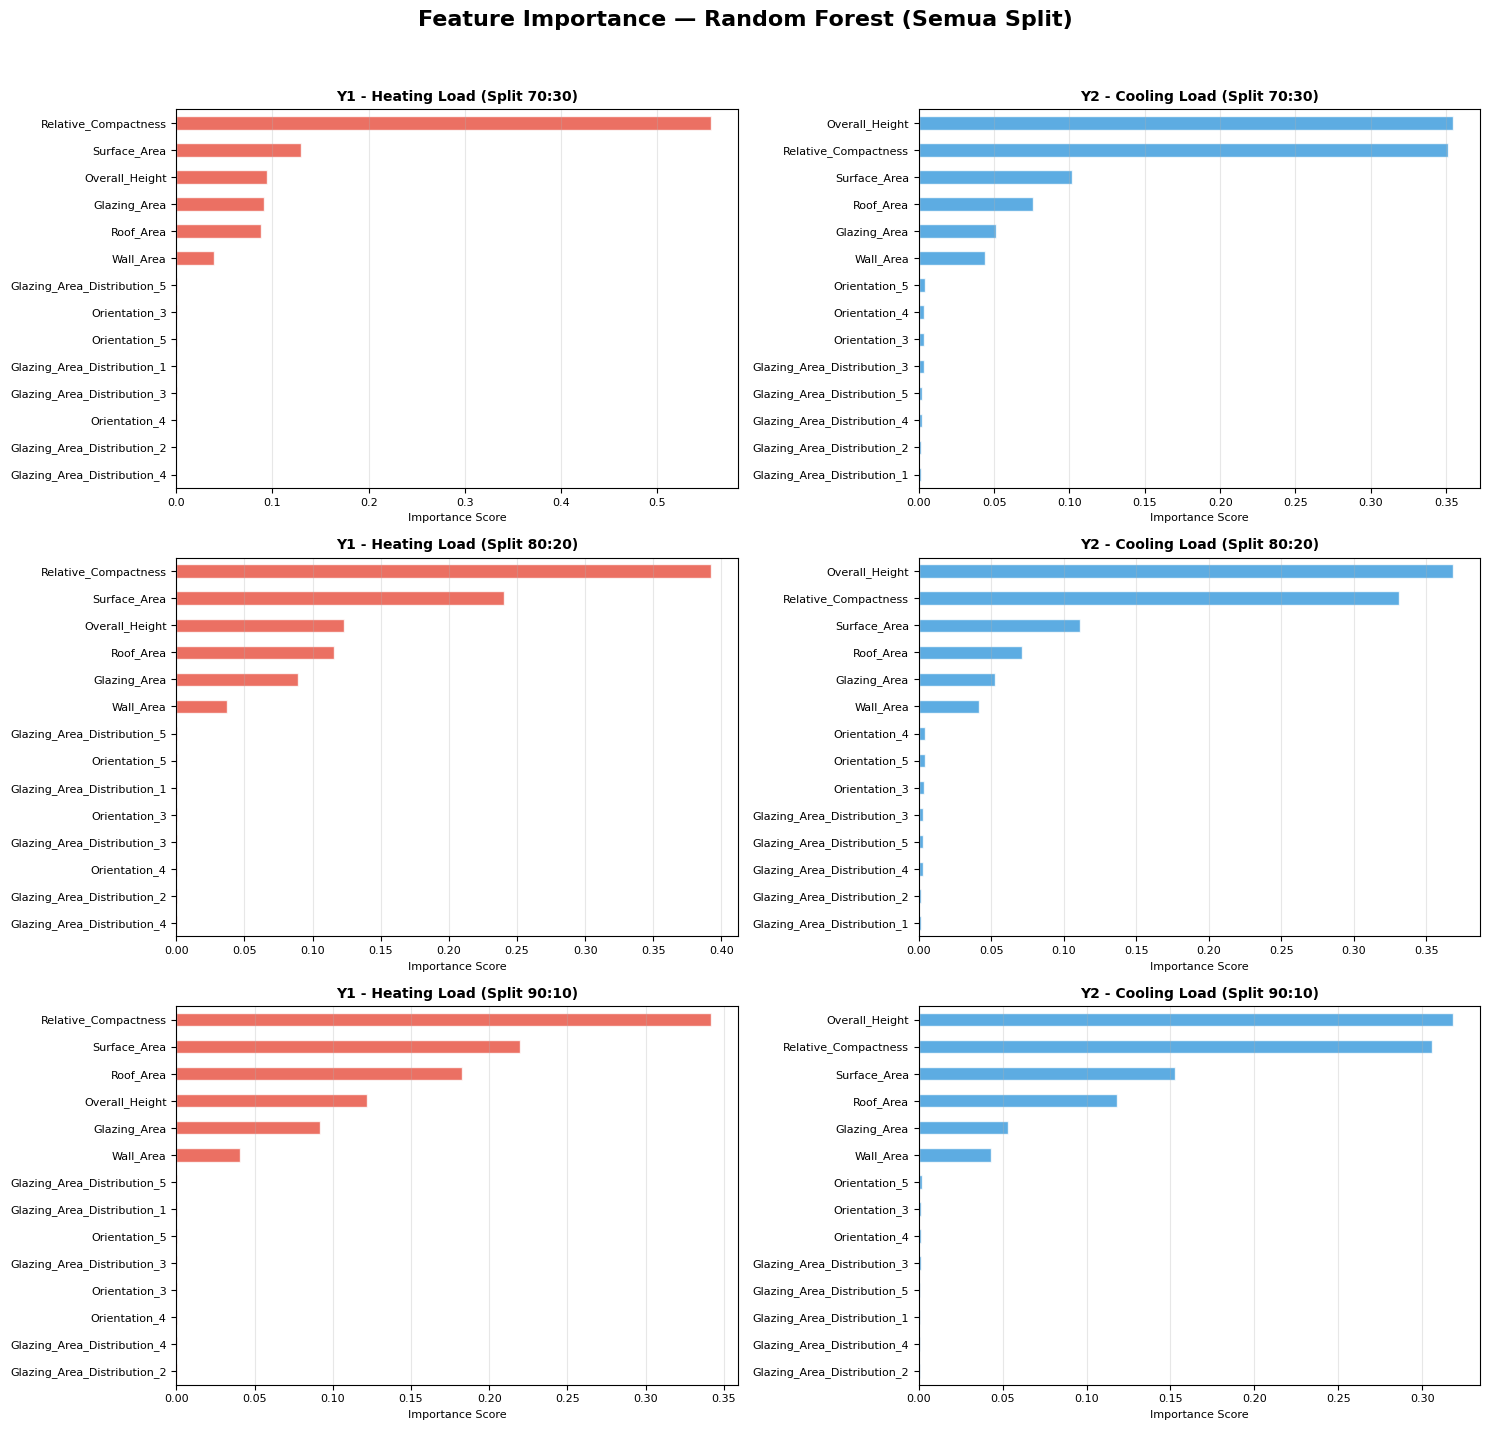

In [ ]:
# 8.4 Feature Importance (Random Forest)
fig_fi, axes_fi = plt.subplots(len(split_labels), 2, figsize=(15, 15))
fig_fi.suptitle('Feature Importance — Random Forest (Semua Split)', fontsize=16, fontweight='bold')

feat_names = X.columns.tolist()

for row_idx, split_name in enumerate(split_labels):
    # Get Random Forest models for Y1 and Y2 for the current split
    rf_model_y1 = best_tuned_y1[split_name]['Random Forest'].named_steps['model']
    rf_model_y2 = best_tuned_y2[split_name]['Random Forest'].named_steps['model']

    # Calculate feature importances
    fi_y1 = pd.Series(rf_model_y1.feature_importances_, index=feat_names).sort_values(ascending=True)
    fi_y2 = pd.Series(rf_model_y2.feature_importances_, index=feat_names).sort_values(ascending=True)

    # Plot for Y1
    ax1 = axes_fi[row_idx, 0]
    fi_y1.plot(kind='barh', ax=ax1, color='#E74C3C', alpha=0.8, edgecolor='white')
    ax1.set_title(f'Y1 - Heating Load (Split {split_name})', fontweight='bold', fontsize=10)
    ax1.set_xlabel('Importance Score', fontsize=8)
    ax1.tick_params(axis='y', labelsize=8)
    ax1.tick_params(axis='x', labelsize=8)
    ax1.grid(axis='x', alpha=0.3)

    # Plot for Y2
    ax2 = axes_fi[row_idx, 1]
    fi_y2.plot(kind='barh', ax=ax2, color='#3498DB', alpha=0.8, edgecolor='white')
    ax2.set_title(f'Y2 - Cooling Load (Split {split_name})', fontweight='bold', fontsize=10)
    ax2.set_xlabel('Importance Score', fontsize=8)
    ax2.tick_params(axis='y', labelsize=8)
    ax2.tick_params(axis='x', labelsize=8)
    ax2.grid(axis='x', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

In [ ]:
#Hasil Evaluasi (Setelah Tuning)
for tgt_label, res_dict in [('Y1 - Heating Load', results_after_y1),
                              ('Y2 - Cooling Load', results_after_y2)]:
    print(f"\n  --- {tgt_label} ---")
    print(f"  {'Split':<8} {'Model':<24} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
    print("  " + "-" * 58)
    for split_name in split_labels:
        for model_name, res in res_dict[split_name].items():
            print(f"  {split_name:<8} {model_name:<24} {res['RMSE']:>8.4f} {res['MAE']:>8.4f} {res['R²']:>8.4f}")
    print("  " + "-" * 58)


  --- Y1 - Heating Load ---
  Split    Model                        RMSE      MAE       R²
  ----------------------------------------------------------
  70:30    Linear Regression          2.8874   2.1017   0.9178
  70:30    Random Forest              0.5076   0.3446   0.9975
  70:30    SVR                        2.6481   1.5717   0.9308
  80:20    Linear Regression          2.8736   2.0609   0.9208
  80:20    Random Forest              0.5240   0.3577   0.9974
  80:20    SVR                        2.5664   1.4448   0.9368
  90:10    Linear Regression          3.0813   2.2986   0.9135
  90:10    Random Forest              0.4779   0.3170   0.9979
  90:10    SVR                        2.7766   1.6758   0.9297
  ----------------------------------------------------------

  --- Y2 - Cooling Load ---
  Split    Model                        RMSE      MAE       R²
  ----------------------------------------------------------
  70:30    Linear Regression          3.2047   2.2873   0.8861
  7

In [ ]:
#Model Terbaik
print("Model Terbaik (Berdasarkan R² Score):")

def find_best_model_per_split(results_dict, target_label):
    best_r2_overall = -1
    best_model_name = ""
    best_split_name = ""

    for split_name, models_data in results_dict.items():
        for model_name, metrics in models_data.items():
            current_r2 = metrics['R²']
            if current_r2 > best_r2_overall:
                best_r2_overall = current_r2
                best_model_name = model_name
                best_split_name = split_name
    print(f"  Target: {target_label}")
    print(f"  → Model Terbaik: {best_model_name} pada Split {best_split_name} dengan R² = {best_r2_overall:.4f}")

find_best_model_per_split(results_after_y1, 'Y1 - Heating Load')
find_best_model_per_split(results_after_y2, 'Y2 - Cooling Load')

Model Terbaik (Berdasarkan R² Score):
  Target: Y1 - Heating Load
  → Model Terbaik: Random Forest pada Split 90:10 dengan R² = 0.9979
  Target: Y2 - Cooling Load
  → Model Terbaik: Random Forest pada Split 70:30 dengan R² = 0.9616


In [ ]:
import joblib

# Model terbaik untuk Y1 (Heating Load) dari split 90:10
rf_model_y1_best = best_tuned_y1['90:10']['Random Forest']

# Model terbaik untuk Y2 (Cooling Load) dari split 70:30
rf_model_y2_best = best_tuned_y2['70:30']['Random Forest']

# Simpan model ke file
joblib.dump(rf_model_y1_best, 'randomforest_y1_bm.pkl')
joblib.dump(rf_model_y2_best, 'randomforest_y2_bm.pkl')

print("✓ Model Random Forest terbaik untuk Heating Load (Y1) telah disimpan sebagai 'randomforest_y1_bm.pkl'")
print("✓ Model Random Forest terbaik untuk Cooling Load (Y2) telah disimpan sebagai 'randomforest_y2_bm.pkl'")

✓ Model Random Forest terbaik untuk Heating Load (Y1) telah disimpan sebagai 'randomforest_y1_bm.pkl'
✓ Model Random Forest terbaik untuk Cooling Load (Y2) telah disimpan sebagai 'randomforest_y2_bm.pkl'


9. Inference

In [ ]:
#9.1 Memuat File Input dan Pra-pemrosesan
# Memuat file input
new_df = pd.read_excel('/content/Inference.xlsx')
# Terapkan One-Hot Encoding yang sama seperti saat pelatihan
# Pastikan kolom kategorikal sama dengan yang digunakan saat df_encoded dibuat
new_df_encoded = pd.get_dummies(
    new_df,
    columns=['Orientation', 'Glazing_Area_Distribution'],
    drop_first=True,
    dtype=int
)

# Pastikan semua kolom fitur (X.columns) ada di new_df_encoded.
# Jika ada kolom yang hilang (misalnya, suatu kategori tidak muncul di data baru),
# tambahkan kolom tersebut dengan nilai 0.
missing_cols = set(X.columns) - set(new_df_encoded.columns)
for c in missing_cols:
    new_df_encoded[c] = 0

# Pastikan urutan kolom sesuai dengan X yang digunakan saat pelatihan model
new_df_processed = new_df_encoded[X.columns]

print("  Data input setelah pra-pemrosesan:")
display(new_df_processed.head())

  Data input setelah pra-pemrosesan:


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Glazing_Area,Orientation_3,Orientation_4,Orientation_5,Glazing_Area_Distribution_1,Glazing_Area_Distribution_2,Glazing_Area_Distribution_3,Glazing_Area_Distribution_4,Glazing_Area_Distribution_5
0,0.78,615,320.5,155,6.0,0.40,0,1,0,0,0,1,0,0
1,0.85,550,300.0,120,7.0,0.10,0,0,0,0,0,0,0,0
2,0.65,700,350.0,200,3.5,0.25,1,0,0,0,1,0,0,0


In [ ]:
# 9.2 Melakukan Prediksi dengan Model Terbaik
rf_model_y1_inference = best_tuned_y1['90:10']['Random Forest']
rf_model_y2_inference = best_tuned_y2['70:30']['Random Forest']
# Melakukan prediksi
predictions_y1_file = rf_model_y1_inference.predict(new_df_processed)
predictions_y2_file = rf_model_y2_inference.predict(new_df_processed)

print("\n  Hasil Prediksi dari File Input:")
for i in range(len(predictions_y1_file)):
    print(f"  Data ke-{i+1}: Heating Load (Y1) = {predictions_y1_file[i]:.2f} kWh/m², Cooling Load (Y2) = {predictions_y2_file[i]:.2f} kWh/m²")


  Hasil Prediksi dari File Input:
  Data ke-1: Heating Load (Y1) = 33.94 kWh/m², Cooling Load (Y2) = 33.20 kWh/m²
  Data ke-2: Heating Load (Y1) = 25.54 kWh/m², Cooling Load (Y2) = 30.22 kWh/m²
  Data ke-3: Heating Load (Y1) = 15.77 kWh/m², Cooling Load (Y2) = 17.07 kWh/m²
